# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [1]:
import pandas as pd

# Load the dataset
df_hotels = pd.read_csv('hotels.csv')

# Display the first few rows
print(df_hotels.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

### ✍️ Your Response: 🔧
1. Somethings that stand out with the data are: the very long lead time for resort hotel #4 and the fact that they all have an arival time for the same date.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [2]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Choose 3-5 numeric features related to customer behavior
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adr', 'total_of_special_requests']

# Create a copy of the dataframe with only the selected features
df_selected = df_hotels[features].copy()

# Drop rows with any missing values in the selected features
# Check for NaNs first
print("Missing values before dropping:")
print(df_selected.isnull().sum())
df_selected.dropna(inplace=True)
print("\nMissing values after dropping:")
print(df_selected.isnull().sum())

# Standardize using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)

# Create a DataFrame from the scaled data for easier inspection if needed
df_scaled = pd.DataFrame(X_scaled, columns=features)

print("\nFirst 5 rows of the scaled data:")
print(df_scaled.head())

Missing values before dropping:
lead_time                    0
stays_in_weekend_nights      0
stays_in_week_nights         0
adr                          0
total_of_special_requests    0
dtype: int64

Missing values after dropping:
lead_time                    0
stays_in_weekend_nights      0
stays_in_week_nights         0
adr                          0
total_of_special_requests    0
dtype: int64

First 5 rows of the scaled data:
   lead_time  stays_in_weekend_nights  stays_in_week_nights       adr  \
0   2.227051                 -0.92889             -1.310240 -2.015038   
1   5.923385                 -0.92889             -1.310240 -2.015038   
2  -0.907814                 -0.92889             -0.786207 -0.530935   
3  -0.851667                 -0.92889             -0.786207 -0.530935   
4  -0.842309                 -0.92889             -0.262174 -0.075810   

   total_of_special_requests  
0                  -0.720694  
1                  -0.720694  
2                  -0.720694  
3  

### ✍️ Your Response: 🔧
1. I selected: lead_time, stays_in_weekend_nights, stays_in_week_nights, adr, and total_of_special_requests. I chose these because are related to customer behavior, and need to be cleaned inorder to be usable in an anayalsis.

2. By looking at these data entries, I expect to discover what the average customer looks like. When are they booking? How long do they stay? How much does the hotel make?


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



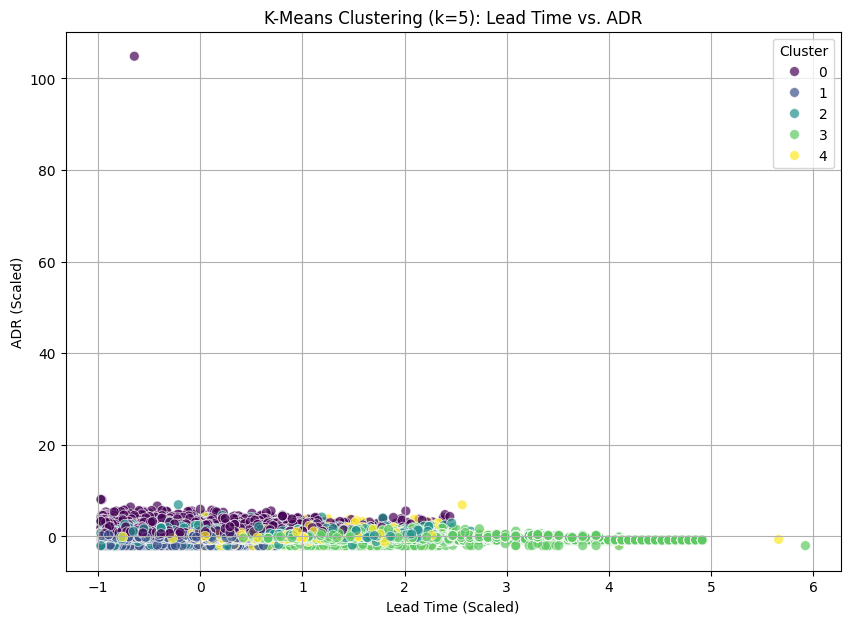

K-Means clustering with k=5 completed.
Cluster distribution:
KMeans_Cluster
0    20793
1    50057
2    14229
3    20632
4    13679
Name: count, dtype: int64


In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a value of k (e.g. 3, 4, or 5)
k = 5

# Fit a KMeans model
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init='auto' or higher value for better results
kmeans_model.fit(X_scaled)

# Predict clusters and assign to each guest
clusters = kmeans_model.predict(X_scaled)
df_selected['KMeans_Cluster'] = clusters
df_scaled['KMeans_Cluster'] = clusters

# Visualize using a scatterplot of 2 features
# Using 'lead_time' and 'adr' for visualization as they often show good separation
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_scaled['lead_time'], y=df_scaled['adr'], hue=df_scaled['KMeans_Cluster'], palette='viridis', s=50, alpha=0.7)
plt.title(f'K-Means Clustering (k={k}): Lead Time vs. ADR')
plt.xlabel('Lead Time (Scaled)')
plt.ylabel('ADR (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print(f"K-Means clustering with k={k} completed.")
print("Cluster distribution:")
print(df_selected['KMeans_Cluster'].value_counts().sort_index())

### ✍️ Your Response: 🔧
1. I chose a K value of 5. I chose this number because it is not super small and should help create the most meaning full groups posiable.

2. After looking at the k clusters, it is posiable to see that there are a few groups. Frist, there is a group of people who have a very large lead time, and create the the least amount of ADR. This makes sense because people who plan trips in advance are most likely saving money and unlkiely to spend a ton. TOn the other hand, we can see a group who have a very small lead time and is willing to spend much more than the "planers" group. There are a few clusters inbetween, but those two are the gist of it all.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


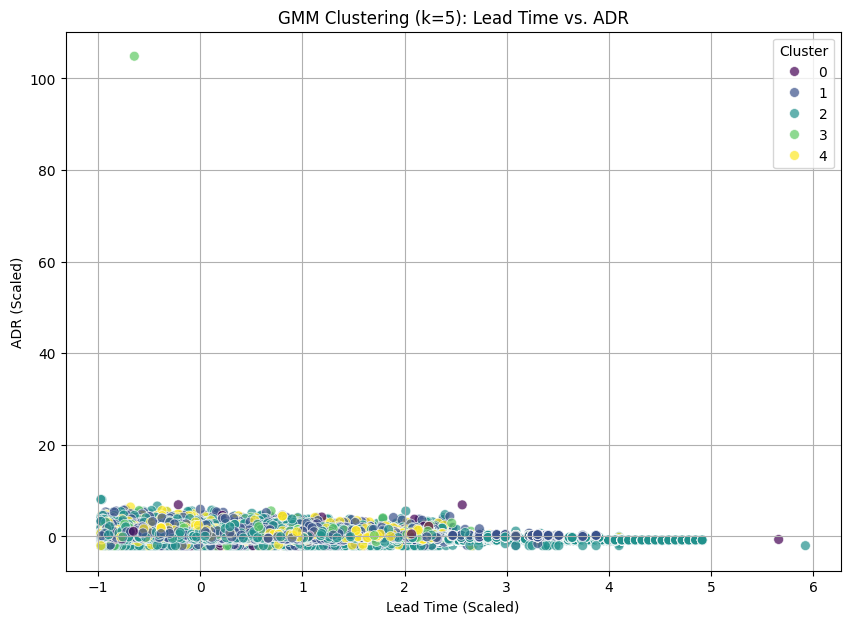

GMM clustering with k=5 completed.
Cluster distribution (based on highest probability assignment):
GMM_Cluster
0     1627
1    32939
2    69530
3     2438
4    12856
Name: count, dtype: int64


In [5]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use the same 'k' value as chosen in Part 3 (from kernel state: k=5)
k = 5

# Fit a GMM model
gmm_model = GaussianMixture(n_components=k, random_state=42, n_init=10) # n_init for GMM is different from KMeans, often for restarts
gmm_model.fit(X_scaled)

# Predict soft clusters (probabilities)
# gmm_model.predict_proba returns an array of shape (n_samples, n_components)
# where each row sums to 1 and represents the probability of belonging to each cluster.
soft_clusters_proba = gmm_model.predict_proba(X_scaled)

# For visualization and comparison, we can assign each point to the cluster
# with the highest probability (hard assignment from soft clustering).
hard_gmm_clusters = np.argmax(soft_clusters_proba, axis=1)

df_selected['GMM_Cluster'] = hard_gmm_clusters
df_scaled['GMM_Cluster'] = hard_gmm_clusters

# Visualize using a scatterplot of 2 features for comparison with KMeans
# Using 'lead_time' and 'adr' again
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_scaled['lead_time'], y=df_scaled['adr'], hue=df_scaled['GMM_Cluster'], palette='viridis', s=50, alpha=0.7)
plt.title(f'GMM Clustering (k={k}): Lead Time vs. ADR')
plt.xlabel('Lead Time (Scaled)')
plt.ylabel('ADR (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print(f"GMM clustering with k={k} completed.")
print("Cluster distribution (based on highest probability assignment):")
print(df_selected['GMM_Cluster'].value_counts().sort_index())

### ✍️ Your Response: 🔧
1. Compared to the Kmeans , the GMM results are very simialr and do not look that diffrent. If anything, I would say they look less segmental, and the groups are more random.

2. GMM would be better at predicting groups in data that has uncertienty. When we do not already know what paterns we are looking for, we would use GMM; however, we know what patters to expect, and therefor want to use Kmeans.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [6]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Define a sample size for evaluation if the dataset is large
sample_size = 10000

# Prepare sampled data for computationally intensive metrics (Silhouette, Davies-Bouldin)
# WCSS for KMeans is from model.inertia_ (full data), for GMM it will be calculated on full data.
if X_scaled.shape[0] > sample_size:
    # Create a random sample of indices
    np.random.seed(42) # for reproducibility
    sample_indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
    X_sample = X_scaled[sample_indices]
    kmeans_clusters_sample = df_selected['KMeans_Cluster'].iloc[sample_indices].values
    gmm_clusters_sample = df_selected['GMM_Cluster'].iloc[sample_indices].values
    print(f"Evaluating Silhouette and Davies-Bouldin using a sample of {X_sample.shape[0]} data points.")
else:
    X_sample = X_scaled
    kmeans_clusters_sample = df_selected['KMeans_Cluster'].values
    gmm_clusters_sample = df_selected['GMM_Cluster'].values
    print(f"Evaluating metrics using the full dataset of {X_sample.shape[0]} data points.")

print("\n--- K-Means Evaluation ---")

# WCSS (Inertia) for K-Means (calculated on full dataset by the model)
kmeans_wcss = kmeans_model.inertia_
print(f"K-Means WCSS (Inertia): {kmeans_wcss:.2f}")

# Silhouette Score for K-Means (on sample)
kmeans_silhouette = silhouette_score(X_sample, kmeans_clusters_sample)
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")

# Davies-Bouldin Index for K-Means (on sample)
kmeans_db_index = davies_bouldin_score(X_sample, kmeans_clusters_sample)
print(f"K-Means Davies-Bouldin Index: {kmeans_db_index:.4f}")


print("\n--- GMM Evaluation ---")

# WCSS for GMM (approximated by summing squared distances to assigned GMM component means on full dataset)
gmm_wcss = 0
for i in range(k): # k is the number of clusters (components)
    cluster_points = X_scaled[hard_gmm_clusters == i]
    if len(cluster_points) > 0:
        component_mean = gmm_model.means_[i]
        gmm_wcss += np.sum((cluster_points - component_mean)**2)

print(f"GMM WCSS (Approximated from hard assignments to component means): {gmm_wcss:.2f}")

# Silhouette Score for GMM (on sample)
gmm_silhouette = silhouette_score(X_sample, gmm_clusters_sample)
print(f"GMM Silhouette Score: {gmm_silhouette:.4f}")

# Davies-Bouldin Index for GMM (on sample)
gmm_db_index = davies_bouldin_score(X_sample, gmm_clusters_sample)
print(f"GMM Davies-Bouldin Index: {gmm_db_index:.4f}")

Evaluating Silhouette and Davies-Bouldin using a sample of 10000 data points.

--- K-Means Evaluation ---
K-Means WCSS (Inertia): 309394.39
K-Means Silhouette Score: 0.2410
K-Means Davies-Bouldin Index: 1.3585

--- GMM Evaluation ---
GMM WCSS (Approximated from hard assignments to component means): 438998.77
GMM Silhouette Score: 0.1310
GMM Davies-Bouldin Index: 2.3501


### ✍️ Your Response: 🔧
1. K-means out preformed GMM during this anayalsis.

2. While they both have their pros and cons, I would prefer K-means to GMM in a bussnies anaysist situation. This is because K-means is better at grouping culsters on cleaned and certin data. If I did not have time to clean the data prior to anaysisis, I would use GMM.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [7]:
# Display the characteristics of each KMeans cluster
kmeans_cluster_characteristics = df_selected.groupby('KMeans_Cluster')[features].mean()

# Sort by a key feature to make differences clear, e.g., 'adr'
kmeans_cluster_characteristics_sorted = kmeans_cluster_characteristics.sort_values(by='adr', ascending=False)

print("K-Means Cluster Characteristics (sorted by ADR):")
print(kmeans_cluster_characteristics_sorted)

# Optionally, also display for GMM clusters for comparison
# (though the prompt explicitly asked for 'each cluster', which implies K-Means from previous steps)
print("\n--- GMM Cluster Characteristics (sorted by ADR): ---")
gmm_cluster_characteristics = df_selected.groupby('GMM_Cluster')[features].mean()
gmm_cluster_characteristics_sorted = gmm_cluster_characteristics.sort_values(by='adr', ascending=False)
print(gmm_cluster_characteristics_sorted)

K-Means Cluster Characteristics (sorted by ADR):
                 lead_time  stays_in_weekend_nights  stays_in_week_nights  \
KMeans_Cluster                                                              
0                66.445775                 0.922811              2.365700   
2                81.369949                 0.914400              2.417106   
4               138.593391                 2.457416              6.010381   
3               275.282619                 0.648895              2.175019   
1                46.008610                 0.630162              1.754740   

                       adr  total_of_special_requests  
KMeans_Cluster                                         
0               168.158364                   0.511711  
2               115.768285                   2.225596  
4                93.202067                   0.518824  
3                87.485823                   0.199690  
1                78.588713                   0.293465  

--- GMM Cluster Ch

### ✍️ Your Response: 🔧
1. In regards to guest behavior, it is aprent that guests have an average lead time of 90 days or 130 days. During week days, they typicly spend one night or 4. They spend most nights during the weeks with an aveage of 3. They most common ADR is around 110 dollars, and they typicly make 1 or 3 special requests.

2. hotels could use this information to either us promotions to spread out consumption or raise rates during specific days when people are most likely to come. If we know people typicaly spend 1 or 3 nights, the hotel could use a promotion to get more guests to spend 3 nights instead of 1. Essentialy, they can use this information to push customers twards spending more moeny.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. One of the most challenging parts of unsupervised learning is preventing the machines from creating fake culstuers and providning false information to the user.

2. I would use clustiering instead of supercised models if I was trying to find new unrecognized groups with in my data sets. This is useful when someone does not have a full understanding of the data.

3. I would explain the value of clustering to a non-technical manager through the concepts of groups. If we can create groups within the data, we can determine how customers will act when certian things happen. We can use the information cuslters give use to more effecively run promotions or sales.

4. This relates to my customized learnign outcome I created in canvase because I want to work with large housing datasets and determine what makes properties valueble vs not. I can use clusters to better help my self recgonisze pattersn and find the defining variables that play the role in determining price.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [9]:
!jupyter nbconvert --to html "assignment_09_clustering_TettelbachIan.ipynb"

[NbConvertApp] Converting notebook assignment_09_clustering_TettelbachIan.ipynb.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 559905 bytes to assignment_09_clustering_TettelbachIan.ipynb.html
